In [73]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
import operator

from pydantic import BaseModel

In [74]:
class llm_state(TypedDict):

    prompt:str
    outline:str
    blog:str
    language_feedback: str
    analysis_feedback: str
    individual_score : Annotated[list[int],operator.add]
    overall_feedback : str
    average_score : int

In [75]:
class feedback_output(BaseModel):
    feedback: str
    score: int

In [76]:
class feedback_output(BaseModel):
    feedback: str
    score: int

In [77]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
load_dotenv(verbose=True)

True

In [78]:
model1 = ChatOpenAI(model='gpt-4o-mini')

In [79]:
model2= ChatOpenAI(model="gpt-4o-mini")
feedback_model = model2.with_structured_output(feedback_output)

In [80]:
graph = StateGraph(llm_state)


In [81]:
from langchain_core.output_parsers import StrOutputParser

parser=StrOutputParser()

In [82]:
def create_outline(state: llm_state):

    initial_prompt = state['prompt']
    outline_prompt = f" create a detailed outline for writing a blog on this topic {initial_prompt}"
    outline = parser.invoke(model1.invoke(outline_prompt))
    return {"outline": outline}


In [83]:
def create_blog(state:llm_state):
    outline = state['outline']
    blog_prompt = f" create a detailed blog for this topic {outline}"
    blog = parser.invoke(model1.invoke(blog_prompt))

    return {"blog" : blog}


In [84]:
def lang_feed(llm_state:llm_state):

    prompt = f" give a deatailed feeback on the language of this blog {llm_state["blog"]}"

    feedback_output = feedback_model.invoke(prompt)

    return {"language_feedback": feedback_output.feedback, "individual_score": [feedback_output.score]}



In [85]:
def analyst_feed(llm_state:llm_state):

    prompt = f" give a deatailed feeback on the anyalsis of the paticular topic this blog is about {llm_state["blog"]}"

    feedback_output = feedback_model.invoke(prompt)

    return {"analysis_feedback": feedback_output.feedback, "individual_score": [feedback_output.score]}



In [86]:
def final_eval(llmstate:llm_state):
    prompt = f"based on these two feedback give a final evalution to the blog. first is the language feedbacck of this blog {llmstate['language_feedback']} and the next is the ability of the blog to anaylse the subject it was written on {llmstate["analysis_feedback"]}"

    overall_feedback = model1.invoke(prompt).content

    #averaging the scores
    average_score = sum(llmstate["individual_score"])/len(llmstate["individual_score"])

    return {"overall_feedback": overall_feedback, "average_score": average_score}

In [87]:
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)
graph.add_node('language_feedback', lang_feed)
graph.add_node('anaylsis_feedback', analyst_feed)
graph.add_node("final_evaluation", final_eval)




In [88]:
graph.add_edge(START,"create_outline")
graph.add_edge("create_outline","create_blog")
graph.add_edge("create_blog","language_feedback")
graph.add_edge("create_blog","anaylsis_feedback")
graph.add_edge("language_feedback","final_evaluation")
graph.add_edge("anaylsis_feedback","final_evaluation")
graph.add_edge("final_evaluation",END)

In [89]:
workflow = graph.compile()

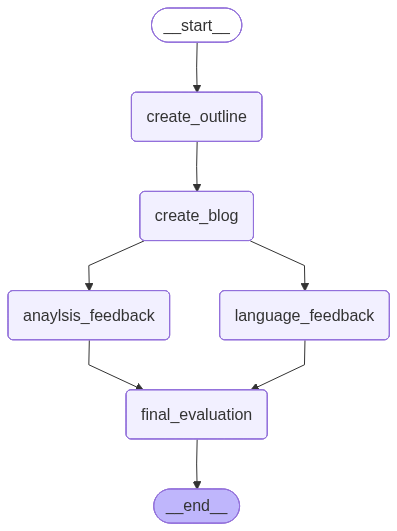

In [90]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [91]:
initial_state = {"prompt": "how to get tech internships in new delhi"}

final_state = workflow.invoke(initial_state)








In [95]:

print(final_state
      )

{'prompt': 'how to get tech internships in new delhi', 'outline': '# Blog Outline: How to Get Tech Internships in New Delhi\n\n## I. Introduction\n   A. Brief overview of the tech industry in New Delhi\n      1. Growth of the technology sector\n      2. Importance of internships for career development\n   B. Purpose of the blog\n      1. To guide readers on obtaining tech internships in New Delhi\n      2. Target audience: Students, recent graduates, and career switchers\n\n## II. Understanding the Internship Landscape\n   A. Types of Tech Internships\n      1. Software Development\n      2. Data Science and Analytics\n      3. UI/UX Design\n      4. Cybersecurity\n      5. IT Support and Networking\n   B. Major Companies Offering Tech Internships\n      1. Startups vs. Established firms\n      2. Notable companies in New Delhi (e.g., Zomato, Paytm, Flipkart, etc.)\n\n## III. Building a Strong Foundation\n   A. Educational Background\n      1. Relevant degrees (Computer Science, Inform